# Configures and Runs MCXCL

In [1]:
# Imports
import math
import numpy as np
import scipy as sp
import pmcxcl
import matplotlib.pyplot as plt
import copy

# Input Allocation

In [2]:
# Path Variables:
repo_path = "/Users/caoze/Documents/GitHub/Photon-Transport-Simulation/"     # Replace with repository path
export_address = "output/mcxcl/"
access_address = "data/media_label/"

# Helpers:
def output_address(subfolder="data/", repository=repo_path):
    out_path = f"{repository}{subfolder}"
    return out_path

def modified_output_address(filename, tag = "flux"):
    name_part = filename.split("_")[0]
    new_name = f"{name_part}_{tag}.npy"         # Tag File Type
    return new_name

In [3]:
# Accessing
filename = "test_label.mat"
access_path = f"{repo_path}{access_address}{filename}"
print("Accessing: " + access_path)

# Open file:
content = sp.io.loadmat(access_path)
print(content.keys())

# Do the same with the parasite data:
filename_para = "test_para_label.mat"
access_path_para = f"{repo_path}{access_address}{filename_para}"
print("Accessing: " + access_path_para)
content_para = sp.io.loadmat(access_path_para)
print(content_para.keys())

Accessing: /Users/caoze/Documents/GitHub/Photon-Transport-Simulation/data/media_label/test_label.mat
dict_keys(['__header__', '__version__', '__globals__', 'masked_ri'])
Accessing: /Users/caoze/Documents/GitHub/Photon-Transport-Simulation/data/media_label/test_para_label.mat
dict_keys(['__header__', '__version__', '__globals__', 'masked_ri'])


# Extraction and Labeling

(212, 376)


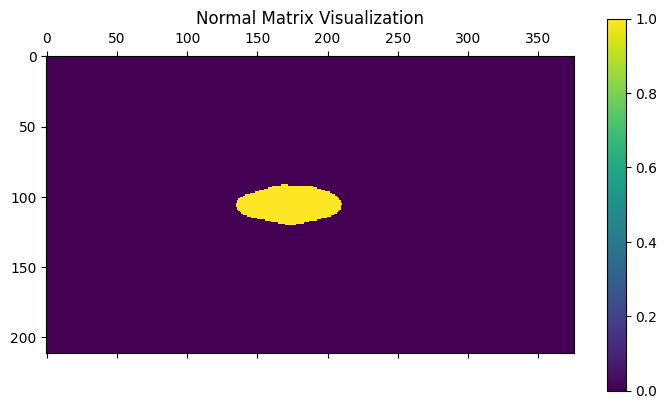

(180, 180)


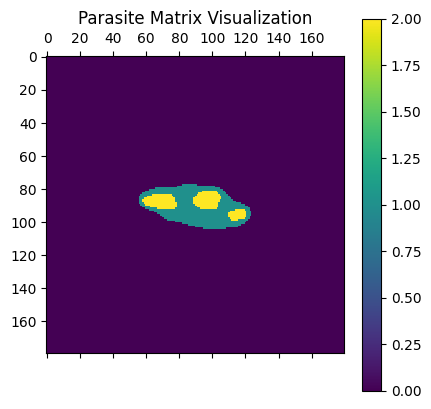

In [4]:
# Retrieve Matrix
extract = content['masked_ri']
pix_num = [extract.shape[1], extract.shape[0]]
print(extract.shape)

# Verify
plt.matshow(extract) 
plt.colorbar() # Creates a colorbar for the plot
plt.title("Normal Matrix Visualization")
plt.show() 

# Retrieve Matrix w/ parasite
extract_para = content_para['masked_ri']
pix_num_para = [extract_para.shape[1], extract_para.shape[0]]
print(extract_para.shape)

# Verify
plt.matshow(extract_para)
plt.colorbar() # Creates a colorbar for the plot
plt.title("Parasite Matrix Visualization")
plt.show()

Gel cutoff at 120
Values:  [0 1 2]
Dimentsions:  (212, 376)


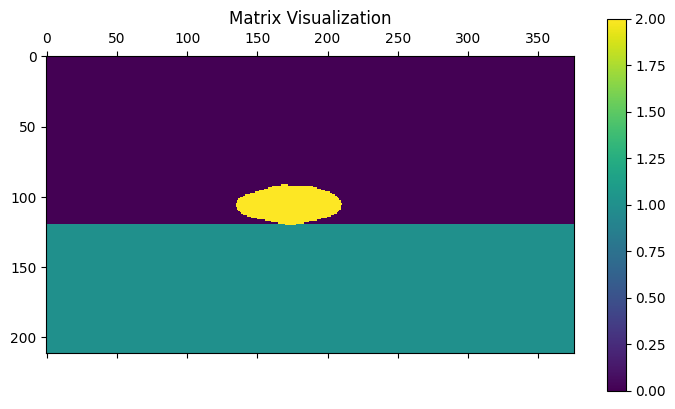

Gel cutoff at 104
Values:  [0. 1. 2. 3.]
Dimensions (180, 180)


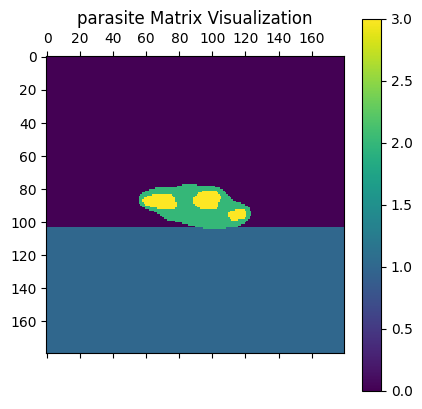

In [12]:
# RI Matrix labeling(0 = air, 1 = gel, 2 = body):
# Padding Labels
air = 0
gel = 1

# Helper
def pad(arr, air, gel, cutoff, depth):

    # Above cutoff
    rows_air = arr[:cutoff, :]
    rows_air[rows_air == 0] = air
    arr[:cutoff, :] = rows_air

    # Below cutoff
    rows_gel = arr[cutoff:depth, :]
    rows_gel[rows_gel == 0] = gel
    arr[cutoff:depth, :] = rows_gel

    return arr
def find_cutoff(array):
    # Find the lowest point on z where the cell is still present, this is the gel line makesure there are consistently 3 consecutive points in the row.
    cell_level= []
    for i in range(array.shape[0]):
        if np.sum(array[i,:]) > 0: # If there are any non-zero values in the row, it means the cell is present
            if i > 1 and np.sum(array[i-1,:]) > 0 and np.sum(array[i-2,:]) > 0: # Check for 3 consecutive rows
                cell_level.append(i)
    return max(cell_level) # The lowest point where the cell is still present


# Padding
cell_mat = np.where(extract > 0, 2, 0)         # Flag Cell Body

cutoff = find_cutoff(cell_mat)
print(f"Gel cutoff at {cutoff}")

padded= pad(cell_mat, air, gel, cutoff, pix_num[1])
print("Values: ", np.unique(padded))
print("Dimentsions: ", padded.shape)

# Visualized
plt.matshow(cell_mat) 
plt.colorbar() # Creates a colorbar for the plot
plt.title("Matrix Visualization")
plt.show() 

# Padding for the parasite data:
cell_mat_para = np.where(extract_para == 2, 3, extract_para)       # Flag parasite Body
cell_mat_para = np.where(extract_para == 1, 2, cell_mat_para)       # Flag Rest of Cell Body

cutoff_para = find_cutoff(cell_mat_para)
print(f"Gel cutoff at {cutoff_para}")

padded_para = pad(cell_mat_para, air, gel, cutoff_para, pix_num[1])
print("Values: ", np.unique(padded_para))
print("Dimensions" , padded_para.shape)

# Visualized
plt.matshow(cell_mat_para) 
plt.colorbar() # Creates a colorbar for the plot
plt.title("parasite Matrix Visualization")
plt.show()


# Bench Mark Testing & Configuration Testing

In [ ]:
# Test Configurations
test_cfg = {
    'nphoton': 1000000, 
    'vol':np.ones([60,60,60],dtype='uint8'), 
    'tstart':0, 'tend':5e-9, 'tstep':5e-10,
    'srcpos': [30,30,0], 'srcdir':[0,0,1], 
    'prop':[[0,0,1,1],[0.005,1,0.01,1.37]]}

In [ ]:
# Built in bench testing
bench = {}
bench["cube60"] = {
    "nphoton": 1000000,
    "vol": np.ones([60, 60, 60], dtype="uint8"),
    "tstart": 0,
    "tend": 5e-9,
    "tstep": 5e-9,
    "srcpos": [29, 29, 0],
    "srcdir": [0, 0, 1],
    "prop": [[0, 0, 1, 1], [0.005, 1, 0.01, 1.37], [0.002, 5, 0.9, 1]],
    "isreflect": 0,
    "seed": 1648335518,
    "session": "cube60",
    "detpos": [[29, 19, 0, 1], [29, 39, 0, 1], [19, 29, 0, 1], [39, 29, 0, 1]],
    "issrcfrom0": 1,
}

bench["cube60b"] = copy.deepcopy(bench["cube60"])
bench["cube60b"]["isreflect"] = 1

bench["cube60planar"] = copy.deepcopy(bench["cube60b"])
bench["cube60planar"]["srctype"] = "planar"
bench["cube60planar"]["srcpos"] = [10, 10, -10]
bench["cube60planar"]["srcparam1"] = [40, 0, 0, 0]
bench["cube60planar"]["srcparam2"] = [0, 40, 0, 0]


In [ ]:
# Test-Run the simulation
print("Running MCXCL simulation...")
res = pmcxcl.run(bench["cube60"])
print("Complete!!!")
print(res.keys())

In [ ]:
# Fetch Data
flux = res["flux"]
detp = res["detp"]
print(flux.shape)
print(detp.shape)

In [ ]:
# Slice: select a single time
slice = flux[30, :, :, 0]  # shape (4,5)

# Display
plt.imshow(slice, cmap='hot', interpolation='nearest')
plt.colorbar(label="Flux")
plt.title(f"Flux at x={30}, t_idx={0}")
plt.show()

# Sample Simulation and Configurations

In [ ]:
# Build Volume
padded = padded.astype(np.uint8)
padded_para = padded_para.astype(np.uint8)

pad = 100
vol = np.repeat(padded[:,:, None], pad, axis = 2)
vol_para = np.repeat(padded_para[:,:, None], pad, axis = 2)

print("Volume saved:", vol.shape)
print("Volume with parasite saved:", vol_para.shape)
print("Tissue labels:", np.unique(vol))
print("Tissue labels with paracyte:", np.unique(vol_para))

Volume saved: (212, 376, 100)
Volume with parasite saved: (180, 180, 100)
Tissue labels: [0 1 2]
Tissue labels with parasite: [0 1 2 3]


In [26]:
# 45 degree across sample:
def corner_to_corner(length, height):
    mag = math.sqrt(length**2 + height**2 + 1)
    return [length/mag, height/mag, 1/mag]
src_dir = corner_to_corner(pix_num[1], pix_num[0])

# PMCXCL Configurations
cfg = {
    'nphoton': 1000000,         # of photons
    'vol':vol, 

    'unitinmm' : 1e-3,

    'tstart':0, 
    'tend':5e-11, 
    'tstep':5e-12,

    'srcpos': [0,0,pad/2],                      # Source Position
    'srcdir':src_dir,             # Source Direction
    'srctype': "pencil",

    'prop':[[0, 0, 1.0, 1.0],           # Air
            [0.005, 0.5, 0.9, 1.357],   # Gel   
            [0.2, 25, 0.98, 1.40]      # RBC
            ]
}

cfg_para = copy.deepcopy(cfg)
cfg_para["srcdir"] = corner_to_corner(pix_num_para[1], pix_num_para[0])
cfg_para["vol"] = vol_para
cfg_para["prop"] = [[0, 0, 1.0, 1.0],           # Air
            [0.005, 0.5, 0.9, 1.357],   # Gel   
            [0.2, 25, 0.98, 1.40],      # RBC
            [1.2, 110, 0.9, 1.37]     # parasite
            ]           

cfg_para_sub = copy.deepcopy(cfg_para)  # Same as parasite, but assume parasite medium is a part of the cell medium
cfg_para["prop"] = [[0, 0, 1.0, 1.0],           # Air
            [0.005, 0.5, 0.9, 1.357],   # Gel   
            [0.2, 25, 0.98, 1.40],      # RBC
            [0.2, 25, 0.98, 1.40]     # parasite
            ]           

In [27]:
# Run the simulation
print("Running MCXCL simulation...")
res = pmcxcl.run(cfg)
print("Complete!!!")
print(res.keys())

Running MCXCL simulation...
nphoton: 1e+06
tstart: 0
tstep: 5e-12
tend: 5e-11
unitinmm: 0.001
Complete!!!
dict_keys(['flux', 'stat'])


In [28]:
# Rerun with parasite configuration
print("Running MCXCL simulation with parasite...")
res_para = pmcxcl.run(cfg_para)
print("Complete!!!")
print(res_para.keys())

Running MCXCL simulation with parasite...
nphoton: 1e+06
tstart: 0
tstep: 5e-12
tend: 5e-11
unitinmm: 0.001
Complete!!!
dict_keys(['flux', 'stat'])


In [29]:
# Rerun with parasite configuration
print("Running MCXCL simulation with parasite...")
res_para_sub = pmcxcl.run(cfg_para_sub)
print("Complete!!!")
print(res_para.keys())

Running MCXCL simulation with parasite...
nphoton: 1e+06
tstart: 0
tstep: 5e-12
tend: 5e-11
unitinmm: 0.001
Complete!!!
dict_keys(['flux', 'stat'])


In [30]:
# Pull out info
flux = res["flux"]
print(flux.shape)

flux_para = res_para["flux"]
print(flux_para.shape)

flux_para_sub = res_para_sub["flux"]
print(flux_para_sub.shape)

(212, 376, 100, 10)
(180, 180, 100, 10)
(180, 180, 100, 10)


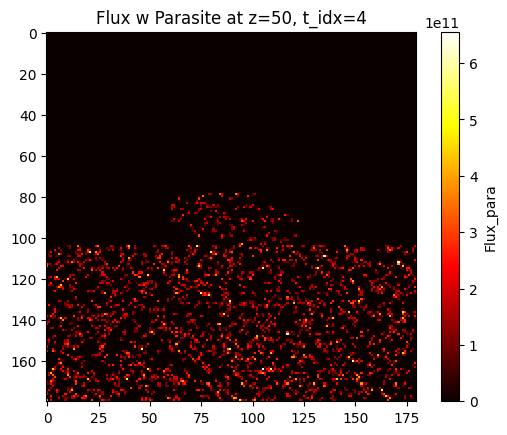

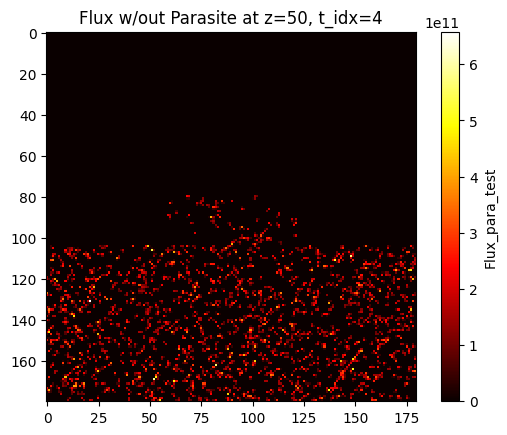

In [37]:
# Visualize
# Pick time index, e.g., 0
t_idx = 4

# Pick a mid-plane slice
mid_pad = int(pad/2)

# Slice: select a single time
para_slice_z = flux_para[:, :, int(mid_pad), t_idx]
para_sub_slice_z = flux_para_sub[:, :, int(mid_pad), t_idx]

# Display
plt.imshow(para_slice_z, cmap='hot', interpolation='nearest')
plt.colorbar(label="Flux_para")
plt.title(f"Flux w Parasite at z={mid_pad}, t_idx={t_idx}")
plt.show()

plt.imshow(para_sub_slice_z, cmap='hot', interpolation='nearest')
plt.colorbar(label="Flux_para_test")
plt.title(f"Flux w/out Parasite at z={mid_pad}, t_idx={t_idx}")
plt.show()

In [34]:
# Saving Output
output_path = output_address(export_address, repo_path)
output_name = modified_output_address(filename)
output_name_para = modified_output_address(filename_para, tag="para_flux")
output_name_para = modified_output_address(filename_para, tag="para_sub_flux")
# Saving
np.save(f"{output_path}{output_name}",flux)
print(f"Successfully saved to: {output_path}{output_name}")

np.save(f"{output_path}{output_name_para}", flux_para)
print(f"Successfully saved to: {output_path}{output_name_para}")

np.save(f"{output_path}{output_name_para}", flux_para_sub)
print(f"successfully saved to: {output_path}{output_name_para}")

Successfully saved to: /Users/caoze/Documents/GitHub/Photon-Transport-Simulation/output/mcxcl/test_flux.npy
Successfully saved to: /Users/caoze/Documents/GitHub/Photon-Transport-Simulation/output/mcxcl/test_para_sub_flux.npy
successfully saved to: /Users/caoze/Documents/GitHub/Photon-Transport-Simulation/output/mcxcl/test_para_sub_flux.npy
